In [1]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
data = np.load("pems08.npz")

traffic = data["data"][:,:,0]

print(traffic.shape)

(17856, 170)


In [3]:
scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(
    traffic
)

print(
    traffic_scaled.shape
)

(17856, 170)


In [4]:
X = []
y = []

sequence_length = 12

for i in range(
    len(traffic_scaled)
    -
    sequence_length
):

    X.append(
        traffic_scaled[
            i:i+sequence_length
        ]
    )

    y.append(
        traffic_scaled[
            i+sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(17844, 12, 170)
(17844, 170)


In [5]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.1)


X_train = X[:train_size]
y_train = y[:train_size]


X_val = X[
    train_size:
    train_size+val_size
]

y_val = y[
    train_size:
    train_size+val_size
]


X_test = X[
    train_size+val_size:
]

y_test = y[
    train_size+val_size:
]


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12490, 12, 170)
(3570, 12, 170)
(1784, 12, 170)


In [6]:
import torch

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [7]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=170,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            170
        )

    def forward(self,x):

        out, _ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

In [9]:
import time

train_start = time.time()

In [10]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            val_loss = criterion(
                predictions,
                y_batch
            )

            total_val_loss += val_loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "LSTM-PEMS08-best.pth"
        )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/30 Train Loss: 0.023773 Val Loss: 0.012100
Epoch 2/30 Train Loss: 0.008249 Val Loss: 0.010275
Epoch 3/30 Train Loss: 0.007092 Val Loss: 0.009523
Epoch 4/30 Train Loss: 0.006701 Val Loss: 0.009209
Epoch 5/30 Train Loss: 0.006402 Val Loss: 0.008871
Epoch 6/30 Train Loss: 0.006151 Val Loss: 0.008617
Epoch 7/30 Train Loss: 0.005984 Val Loss: 0.008722
Epoch 8/30 Train Loss: 0.005807 Val Loss: 0.008438
Epoch 9/30 Train Loss: 0.005540 Val Loss: 0.008303
Epoch 10/30 Train Loss: 0.005313 Val Loss: 0.008015
Epoch 11/30 Train Loss: 0.005157 Val Loss: 0.007932
Epoch 12/30 Train Loss: 0.005091 Val Loss: 0.007921
Epoch 13/30 Train Loss: 0.005019 Val Loss: 0.007890
Epoch 14/30 Train Loss: 0.004960 Val Loss: 0.007896
Epoch 15/30 Train Loss: 0.004942 Val Loss: 0.007996
Epoch 16/30 Train Loss: 0.004878 Val Loss: 0.008044
Epoch 17/30 Train Loss: 0.004793 Val Loss: 0.007989
Epoch 18/30 Train Loss: 0.004701 Val Loss: 0.007950
Epoch 19/30 Train Loss: 0.004652 Val Loss: 0.007952
Epoch 20/30 Train Los

In [11]:
train_time = time.time() - train_start

print("Time Taken:", train_time)

Time Taken: 110.25940871238708


In [12]:
model.load_state_dict(
    torch.load(
        "LSTM-PEMS08-best.pth",
        map_location="cpu"
    )
)


<All keys matched successfully>

In [13]:
model.eval()

infer_start = time.time()
with torch.no_grad():

    predictions = model(
        X_test
    )

predictions = predictions.numpy()
infer_time = time.time() - infer_start
print("Infer Time:", infer_time)

true_values = y_test.numpy()

mae = mean_absolute_error(
    true_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        true_values,
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

Infer Time: 0.14075350761413574
MAE: 0.0499047115445137
RMSE: 0.07463853475939154


In [14]:
from sklearn.metrics import r2_score

mape = np.mean(
    np.abs((true_values - predictions) /
           np.maximum(np.abs(true_values), 1e-6))
) * 100

r2 = r2_score(
    true_values.flatten(),
    predictions.flatten()
)
print("MAPE:", mape)
print("R2:", r2)

MAPE: 21417.404
R2: 0.9100589156150818


In [15]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", params)

Parameters: 71466


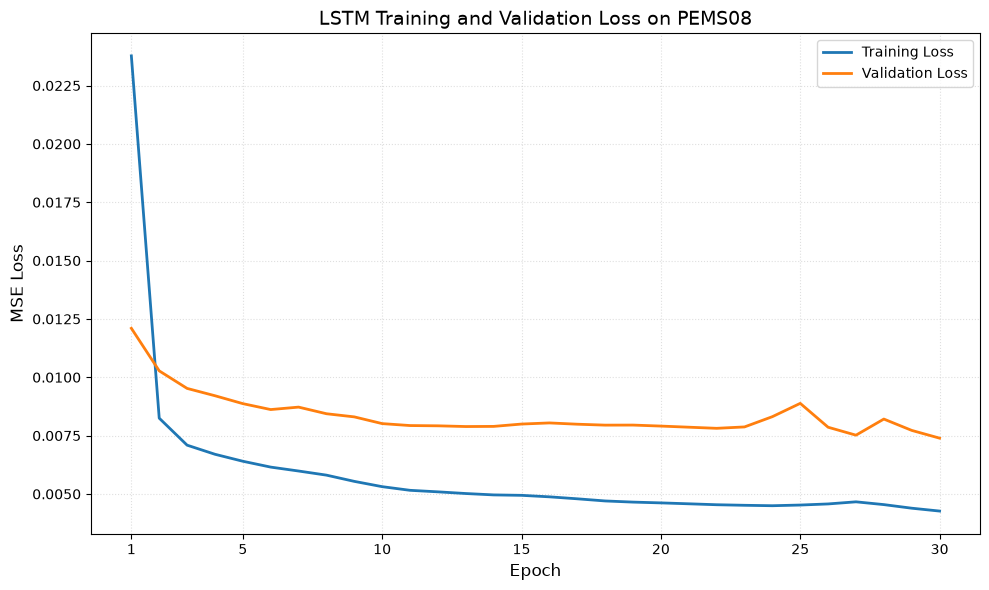

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_losses,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)

plt.title(
    "LSTM Training and Validation Loss on PEMS08",
    fontsize=14
)

plt.xticks([1, 5, 10, 15, 20, 25, 30])

plt.grid(
    True,
    linestyle=":",
    alpha=0.4
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "LSTM-PEMS08-validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()